# Descargar el Dataset de kaggle 


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nih-chest-xrays/data")

print("Path to dataset files:", path)

100%|██████████| 42.0G/42.0G [03:51<00:00, 195MB/s] 


Extracting files...
Path to dataset files: /home/project_cv_um/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3


La celda de abajo mueve los archivos de la carpeta del cache de kagglehub a la carpeta del proyecto. 


In [8]:

from pathlib import Path
import shutil
from tqdm.notebook import tqdm

src = Path(path)
dst = Path("./data/chestxray")

dst.mkdir(parents=True, exist_ok=True)

items = list(src.iterdir())
for p in tqdm(items, desc="Moviendo archivos"):
    target = dst / p.name
    try:
        # mover archivo o carpeta
        shutil.move(str(p), str(target))
    except Exception as e:
        print(f"Error moviendo {p}: {e}")


Moviendo archivos:   0%|          | 0/20 [00:00<?, ?it/s]

# imports necesarios y verificación de la carpeta con el dataset

In [1]:

from pathlib import Path
import sys
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt


data_path = Path("./data/chestxray")


print("Data encontrada:", data_path.exists())

Data encontrada: True


# Preparación Entorno

Esta celda carga las clases de python locales

In [2]:
code_dir = (Path.cwd() / "code").resolve()
print("code_dir:", code_dir)
if not code_dir.exists():
    raise FileNotFoundError(f"No existe la carpeta {code_dir}")

if str(code_dir) not in sys.path:
    sys.path.insert(0, str(code_dir))
    print("Añadido a sys.path")

# listar archivos relevantes
for p in sorted(code_dir.iterdir()):
    print("-", p.name)
from genCSVMap import prepare_labels_dataset

code_dir: /home/project_cv_um/ProyectoCNN/code
Añadido a sys.path
- .ipynb_checkpoints
- CNNTransformerFusion.py
- __pycache__
- datasetMgr.py
- genCSVMap.py


In [3]:
df = pd.read_csv(data_path / "Data_Entry_2017.csv")
print(df.head())

labels_df, train_val_df, test_df = prepare_labels_dataset(
    base_path='./data/chestxray'
)


train_df, val_df = train_test_split( train_val_df, test_size=0.2, random_state=42)

print(f"Train: {len(train_df)} imágenes")
print(f"Val:   {len(val_df)} imágenes")
print(f"Test:  {len(test_df)} imágenes")

        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.143  0.143          NaN 

One-hot encoding diseases: 100%|██████████| 14/14 [00:00<00:00, 26.50it/s]


Buscando imágenes en subcarpetas (extensiones png/jpg/jpeg) ...
112120 archivos de imágenes encontrados en la estructura de carpetas.


Resolviendo paths: 100%|██████████| 112120/112120 [00:05<00:00, 18713.75it/s]


Resolución: 112120 encontrados, 0 no encontrados.
0 entradas con múltiples candidatos (usa 'All_Paths' para ver opciones).
Dataset procesado guardado en: ./data/chestxray/IdxDataset.csv
Train/Val (marcados): 86524 imágenes
Test (marcados): 25596 imágenes
Total filas en processed_df (sin eliminar): 112120

Ejemplo (primeras 5 filas de processed_df):
        Image_Index                                               Path  \
0  00000001_000.png  data/chestxray/images_001/images/00000001_000.png   
1  00000001_001.png  data/chestxray/images_001/images/00000001_001.png   
2  00000001_002.png  data/chestxray/images_001/images/00000001_002.png   
3  00000002_000.png  data/chestxray/images_001/images/00000002_000.png   
4  00000003_000.png  data/chestxray/images_001/images/00000003_000.png   

                                           All_Paths  Num_Candidates  \
0  [data/chestxray/images_001/images/00000001_000...               1   
1  [data/chestxray/images_001/images/00000001_001...        

# Transforming

In [4]:
DISEASE_COLUMNS = [
    'Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax',
    'Edema', 'Emphysema', 'Fibrosis', 'Effusion', 'Pneumonia',
    'Pleural_Thickening', 'Cardiomegaly', 'Nodule', 'Mass', 'Hernia'
]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAdjustSharpness(2, p=0.5),
    transforms.RandomAutocontrast(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
from datasetMgr import datasetMgr

train_dataset = datasetMgr(dataframe=train_df,disease_columns=DISEASE_COLUMNS,transform=train_transform)
val_dataset = datasetMgr(dataframe=val_df,disease_columns=DISEASE_COLUMNS,transform=val_transform)
test_dataset = datasetMgr(dataframe=test_df,disease_columns=DISEASE_COLUMNS,transform=val_transform)

print(f"Train dataset: {len(train_dataset)} muestras")
print(f"Val dataset:   {len(val_dataset)} muestras")
print(f"Test dataset:  {len(test_dataset)} muestras")


Train dataset: 69219 muestras
Val dataset:   17305 muestras
Test dataset:  25596 muestras


## Dataloader

In [5]:
BATCH_SIZE = 64
NUM_WORKERS = 7 #vCPU -1

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,prefetch_factor=4)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,prefetch_factor=4)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,prefetch_factor=4)

print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")
print(f"   Test batches:  {len(test_loader)}")

   Train batches: 1082
   Val batches:   271
   Test batches:  400


### Dataloaders Creados

In [6]:
images, meta, labels = next(iter(train_loader))

print(f"\nBatch de entrenamiento:")
print(f"Imágenes shape: {images.shape}")      # Debe ser (32, 3, 224, 224) para ser compatible por RESNET
print(f"Labels shape:   {labels.shape}")      # Debe ser (32, 14) IDEM
print(f"Imágenes - Min: {images.min():.3f}, Max: {images.max():.3f}")
print(f"Labels - Min:   {labels.min():.0f}, Max: {labels.max():.0f}")


print(f"\n  Labels por enfermedad en este batch:")
for i, disease in enumerate(DISEASE_COLUMNS):
    count = labels[:, i].sum().item()
    print(f"    {disease:20s}: {count:.0f}/{BATCH_SIZE}")


Batch de entrenamiento:
Imágenes shape: torch.Size([64, 3, 224, 224])
Labels shape:   torch.Size([64, 14])
Imágenes - Min: -2.118, Max: 2.640
Labels - Min:   0, Max: 1

  Labels por enfermedad en este batch:
    Atelectasis         : 3/64
    Consolidation       : 0/64
    Infiltration        : 6/64
    Pneumothorax        : 2/64
    Edema               : 1/64
    Emphysema           : 2/64
    Fibrosis            : 1/64
    Effusion            : 6/64
    Pneumonia           : 0/64
    Pleural_Thickening  : 0/64
    Cardiomegaly        : 0/64
    Nodule              : 1/64
    Mass                : 1/64
    Hernia              : 0/64



Visualizando imágenes de ejemplo...


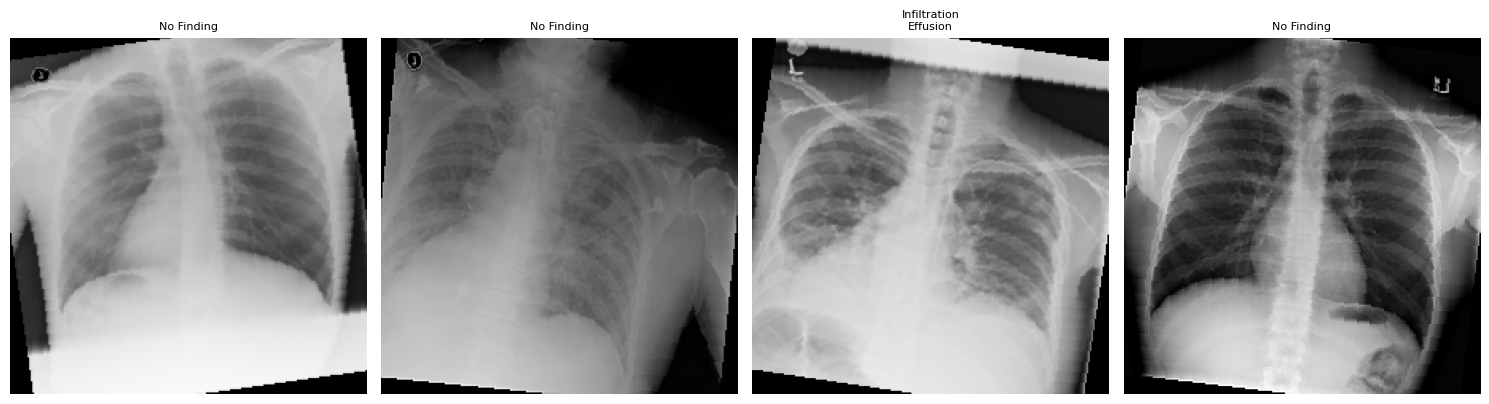

In [7]:

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

def show_batch(images, labels, n=4):
    fig, axes = plt.subplots(1, n, figsize=(15, 4))

    for i in range(n):
        img = denormalize(images[i].cpu())
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        diseases = [DISEASE_COLUMNS[j] for j in range(14) if labels[i, j] == 1]
        diseases_str = '\n'.join(diseases[:3]) if diseases else 'No Finding'

        axes[i].imshow(img)
        axes[i].set_title(diseases_str, fontsize=8)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("\nVisualizando imágenes de ejemplo...")
show_batch(images, labels, n=4)

## Transfer Learning

In [8]:
import torch.nn as nn
from torchvision import models
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
num_classes = len(DISEASE_COLUMNS)

Usando dispositivo: cuda


### DenseNet121

### Cálculo de pos_weight para BCEWithLogitsLoss



El parámetro `pos_weight` en `BCEWithLogitsLoss` permite **balancear clases desbalanceadas** en problemas de clasificación binaria o multi-label.


En el dataset de ChestX-ray, las clases están muy desbalanceadas:
- Algunas enfermedades aparecen en muy pocas imágenes (ej: Hernia ~200 casos)
- Otras son más frecuentes (ej: Infiltration ~19,000 casos)
- La mayoría de las imágenes son negativas para cada clase específica

Sin pos_weight, el modelo podría aprender a **predecir siempre negativo** para clases raras, obteniendo alta precisión pero fallando en detectar casos positivos importantes.


Para cada clase $i$:

$$\text{pos\_weight}_i = \frac{\text{neg\_count}_i}{\text{pos\_count}_i}$$

**Interpretación**: Si una clase tiene 10,000 negativos y 1,000 positivos, pos_weight = 10.0
- Esto hace que el modelo **penalice 10× más** los errores en casos positivos
- Compensa el desbalance y fuerza al modelo a aprender a detectar casos raros

#### Clipping

Se aplica un límite máximo (`max_weight = 100.0`) para evitar:
- Pesos extremadamente grandes en clases muy raras
- Inestabilidad numérica durante el entrenamiento
- Sobreajuste a clases con muy pocos ejemplos

#### Resultado

El vector `pos_weight_tensor` se pasa a `BCEWithLogitsLoss`, que ajusta la función de pérdida:

$$\text{Loss} = -\frac{1}{N}\sum_{i=1}^{N}\left[ w_i \cdot y_i \cdot \log(\sigma(x_i)) + (1-y_i) \cdot \log(1-\sigma(x_i)) \right]$$

donde $w_i$ = pos_weight cuando $y_i = 1$ (caso positivo)

In [12]:
from CNNTransformerFusion import CNNTransformerFusion
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score
import time
import copy



num_epochs = 100                
patience = 8                    
best_metric = -np.inf           
model = CNNTransformerFusion(num_classes=num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

pos_counts = np.zeros(num_classes, dtype=np.float64)
total_samples = 0


print("Computando pos_weight a partir de train_loader (conteo de positivos por clase)...")
for _, _, lbls in train_loader:
    if isinstance(lbls, torch.Tensor):
        lbls_np = lbls.cpu().numpy()
    else:
        lbls_np = np.array(lbls)
    pos_counts += lbls_np.sum(axis=0)
    total_samples += lbls_np.shape[0]

neg_counts = total_samples - pos_counts
# evitar division por cero y pesos extremadamente grandes
eps = 1e-6
raw_pos_weight = neg_counts / (pos_counts + eps)

max_weight = 100.0
pos_weight_clipped = np.minimum(raw_pos_weight, max_weight)

pos_weight_tensor = torch.tensor(pos_weight_clipped, dtype=torch.float32).to(device)
print("total_samples:", total_samples)
print("positives per class:", pos_counts.astype(int))
print("raw pos_weight:", np.round(raw_pos_weight, 3))
print("clipped pos_weight:", np.round(pos_weight_clipped, 3))

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)


Computando pos_weight a partir de train_loader (conteo de positivos por clase)...
total_samples: 69219
positives per class: [ 6575  2244 11034  2098  1122  1127   984  6896   696  1765  1348  3787
  3226   110]
raw pos_weight: [  9.528  29.846   5.273  31.993  60.693  60.419  69.345   9.038  98.453
  38.218  50.349  17.278  20.457 628.264]
clipped pos_weight: [  9.528  29.846   5.273  31.993  60.693  60.419  69.345   9.038  98.453
  38.218  50.349  17.278  20.457 100.   ]


Entrena los epochs hasta 100. En cada iteración corre un epoch de validación y toma el epoch con mejor val_mean_auc.
Si no mejora en 3 iteraciones, baja el learning rate en cada iteracion hasta la nro 8.
Cuando pasan 8 iteraciones sin mejoras deja de entrenar. 

In [ ]:

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                       factor=0.5, patience=3)
# mode='max' porque vamos a monitorizar mean AUC (mayor mejor).

best_state = None
best_epoch = 0
epochs_no_improve = 0
history = {'train_loss': [], 'val_loss': [], 'val_mean_auc': []}

def compute_mean_auc(y_true, y_probs):
    aucs = []
    for i in range(y_true.shape[1]):
        if np.sum(y_true[:, i]) > 0 and np.sum(y_true[:, i]) < len(y_true):  # requiere positivos y negativos
            aucs.append(roc_auc_score(y_true[:, i], y_probs[:, i]))
    if len(aucs) == 0:
        return np.nan
    return np.mean(aucs)

for epoch in range(1, num_epochs+1):
    t0 = time.time()
    # TRAIN 
    model.train()
    running_loss = 0.0
    for images, meta, labels in train_loader:
        images, meta, labels = images.to(device, non_blocking=True), meta.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images, meta)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    train_loss = running_loss / len(train_loader.dataset)
    history['train_loss'].append(train_loss)

    # VALIDATION 
    model.eval()
    val_loss = 0.0
    all_outputs = []
    all_labels = []
    with torch.no_grad():
        for images, meta, labels in val_loader:
            images, meta, labels = images.to(device), meta.to(device), labels.to(device)
            outputs = model(images, meta)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            all_outputs.append(outputs.cpu().sigmoid().numpy())   # convertir logits -> probs
            all_labels.append(labels.cpu().numpy())

    val_loss = val_loss / len(val_loader.dataset)
    history['val_loss'].append(val_loss)

    all_outputs = np.concatenate(all_outputs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    val_mean_auc = compute_mean_auc(all_labels, all_outputs)
    history['val_mean_auc'].append(val_mean_auc if not np.isnan(val_mean_auc) else 0.0)

    
    # Aquí reducimos LR si val_mean_auc no mejora (mode='max' en scheduler)
    scheduler.step(val_mean_auc if not np.isnan(val_mean_auc) else 0.0)

    #early stopper
    is_best = (val_mean_auc is not np.nan) and (val_mean_auc > best_metric)
    if is_best:
        best_metric = val_mean_auc
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(best_state, "best_model.pth")
        print(f"Epoch {epoch}: New best model (val_mean_auc={val_mean_auc:.4f}) saved.")
    else:
        epochs_no_improve += 1

    print(f"Epoch {epoch}/{num_epochs} - train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}  val_mean_auc: {val_mean_auc:.4f}  time: {time.time()-t0:.1f}s")

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered. No improvement in {patience} epochs.")
        break

print(f"Training finished. Best epoch: {best_epoch} with val_mean_auc={best_metric:.4f}")
# carga el mejor modelo
if best_state is not None:
    model.load_state_dict(best_state)


Epoch 1: ⭐ New best model (val_mean_auc=0.7674) saved.
Epoch 1/100 - train_loss: 1.1241  val_loss: 1.0630  val_mean_auc: 0.7674  time: 452.0s
Epoch 2: ⭐ New best model (val_mean_auc=0.7810) saved.
Epoch 2/100 - train_loss: 1.0224  val_loss: 1.0506  val_mean_auc: 0.7810  time: 454.9s
Epoch 3: ⭐ New best model (val_mean_auc=0.8113) saved.
Epoch 3/100 - train_loss: 0.9628  val_loss: 0.9705  val_mean_auc: 0.8113  time: 455.0s
Epoch 4: ⭐ New best model (val_mean_auc=0.8144) saved.
Epoch 4/100 - train_loss: 0.9273  val_loss: 0.9788  val_mean_auc: 0.8144  time: 456.3s
Epoch 5: ⭐ New best model (val_mean_auc=0.8227) saved.
Epoch 5/100 - train_loss: 0.9059  val_loss: 0.9502  val_mean_auc: 0.8227  time: 454.7s
Epoch 6: ⭐ New best model (val_mean_auc=0.8279) saved.
Epoch 6/100 - train_loss: 0.8806  val_loss: 0.9317  val_mean_auc: 0.8279  time: 456.7s
Epoch 7/100 - train_loss: 0.8591  val_loss: 0.9523  val_mean_auc: 0.8266  time: 455.0s
Epoch 8: ⭐ New best model (val_mean_auc=0.8285) saved.
Epoch 

# Cargar modelo guardado



In [9]:
import torch
from CNNTransformerFusion import CNNTransformerFusion
from pathlib import Path

# Verificar que el archivo existe
model_path = Path("best_model.pth")
if not model_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo {model_path}. Asegúrate de haber entrenado el modelo primero.")

# Crear la arquitectura del modelo
model = CNNTransformerFusion(num_classes=num_classes).to(device)

# Cargar los pesos guardados
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print(f"✅ Modelo cargado exitosamente desde {model_path}")
print(f"   - Arquitectura: CNNTransformerFusion")
print(f"   - Num clases: {num_classes}")
print(f"   - Device: {device}")

✅ Modelo cargado exitosamente desde best_model.pth
   - Arquitectura: CNNTransformerFusion
   - Num clases: 14
   - Device: cuda


### Cálculo de thresholds óptimos por clase



Para convertir probabilidades en etiquetas (0/1), calculamos un **umbral óptimo por clase** usando la estadística de **Youden (J)** sobre la curva ROC.

#### Procedimiento

- Entradas:
  - `all_outputs`: salidas del modelo por clase. Si son logits, se convierten a probabilidades con `sigmoid`.
  - `all_labels`: etiquetas verdaderas 0/1 por clase.

- Por cada clase i:
  1. Tomar `y_true = labels[:, i]` y `y_prob = probs[:, i]` (probs en [0,1]).
  2. Calcular la curva ROC: `fpr, tpr, thr = roc_curve(y_true, y_prob)`.
  3. Calcular **Youden's J** para cada punto: `J = tpr - fpr` (equivalente a sensibilidad + especificidad − 1).
  4. Elegir el umbral que maximiza J: `best_idx = argmax(J)` y `threshold_i = thr[best_idx]`.

- Casos límite:
  - Si una clase no tiene suficientes positivos/negativos (todo 0 o todo 1), no se puede construir ROC de forma útil; se usa un valor por defecto `0.5`.

- Resultado:
  - Se obtiene un vector `thresholds` con un umbral por clase.
  - Las celdas posteriores reutilizan estos umbrales precalculados para evitar duplicación de código.

### Ventaja de Youden's J

Maximiza el balance entre sensibilidad (recall) y especificidad.

In [15]:
from sklearn.metrics import roc_curve
thresholds = []
for i in range(num_classes):
    y_true = all_labels[:, i]
    y_prob = 1 / (1 + np.exp(-all_outputs[:, i]))
    if np.sum(y_true) > 0:
        fpr, tpr, thr = roc_curve(y_true, y_prob)
        j_scores = tpr - fpr
        best_t = thr[np.argmax(j_scores)]
        thresholds.append(best_t)
    else:
        thresholds.append(0.5)
print("Thresholds óptimos por clase:", np.round(thresholds, 3))


Thresholds óptimos por clase: [0.475 0.544 0.432 0.373 0.379 0.47  0.581 0.561 0.477 0.655 0.356 0.301
 0.603 0.535]


#### Evaluacion DenseNet121

In [20]:

model.eval()
total_loss = 0.0
all_outputs = []
all_labels = []


with torch.no_grad():
    for images, meta, labels in tqdm(test_loader, desc="Evaluando"):
        images, meta, labels = images.to(device), meta.to(device), labels.to(device)
        outputs = model(images, meta)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        
        all_outputs.append(outputs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_outputs = np.concatenate(all_outputs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print(f"Test Loss: {total_loss / len(test_loader.dataset):.4f}")

Evaluando: 100%|██████████| 400/400 [02:03<00:00,  3.25it/s]


Test Loss: 1.9004


#### Evaluación AUC

In [ ]:
try:
    auc_scores = []
    for i in range(num_classes):
        if np.sum(all_labels[:, i]) > 0:
            probs = 1 / (1 + np.exp(-all_outputs[:, i]))
            auc = roc_auc_score(all_labels[:, i], probs)
            auc_scores.append(auc)
        else:
            auc_scores.append(np.nan)
    mean_auc = np.nanmean(auc_scores)
    print(f"\nAUC promedio: {mean_auc:.4f}")
    print("AUC por clase:", np.round(auc_scores, 3))
except Exception as e:
    print("Error al calcular AUC:", e)


AUC promedio: 0.7927
AUC por clase: [0.758 0.731 0.689 0.846 0.822 0.902 0.801 0.812 0.681 0.749 0.875 0.737
 0.802 0.893]


#### Análisis detallado: histogramas y métricas usando umbrales óptimos

Esta celda genera:
- Histogramas de probabilidades predichas por el modelo para cada clase, indicando el umbral óptimo
- Tabla con los valores de precisión, recall, f1-score y miss rate para cada clase



✓ Reutilizando umbrales óptimos precalculados de celdas anteriores:
   - Atelectasis: 0.475
   - Consolidation: 0.544
   - Infiltration: 0.432
   - Pneumothorax: 0.373
   - Edema: 0.379
   - Emphysema: 0.470
   - Fibrosis: 0.581
   - Effusion: 0.561
   - Pneumonia: 0.477
   - Pleural_Thickening: 0.655
   - Cardiomegaly: 0.356
   - Nodule: 0.301
   - Mass: 0.603
   - Hernia: 0.535

Resumen global de samples:
 - Total samples: 25596
 - Samples sin patología en GT (all zeros): 9861 (38.53%)
 - Samples donde modelo no predijo ninguna clase: 0 (0.00%)
 - Entre imágenes enfermas, misses (no_pred & tiene GT>0): 0 (0.00%)


,class,threshold,TP,FP,FN,TN,positives_gt,precision,recall,f1,accuracy,miss_rate_pct
12,Mass,0.602790,3,9,1745,23839,1748,0.250000,0.001716,0.003409,0.931474,99.828375
9,Pleural_Thickening,0.654512,43,804,1100,23649,1143,0.050767,0.037620,0.043216,0.925613,96.237970
6,Fibrosis,0.580986,98,4827,337,20334,435,0.019898,0.225287,0.036567,0.798250,77.471264
7,Effusion,0.561465,2142,8172,2516,12766,4658,0.207679,0.459854,0.286134,0.582435,54.014599
1,Consolidation,0.544067,861,10549,954,13232,1815,0.075460,0.474380,0.130208,0.550594,52.561983
5,Emphysema,0.470491,728,15765,365,8738,1093,0.044140,0.666057,0.082793,0.369823,33.394328
4,Edema,0.379137,747,19691,178,4980,925,0.036550,0.807568,0.069934,0.223746,19.243243
11,Nodule,0.301449,1470,21377,153,2596,1623,0.064341,0.905730,0.120147,0.158853,9.426987
10,Cardiomegaly,0.356116,1001,22915,68,1612,1069,0.041855,0.936389,0.080128,0.102086,6.361085
13,Hernia,0.534819,85,25408,1,102,86,0.003334,0.988372,0.006646,0.007306,1.162791



Per-class summary saved to eval_outputs_per_class_summary.csv
Saved histograms to eval_outputs_prob_histograms.png


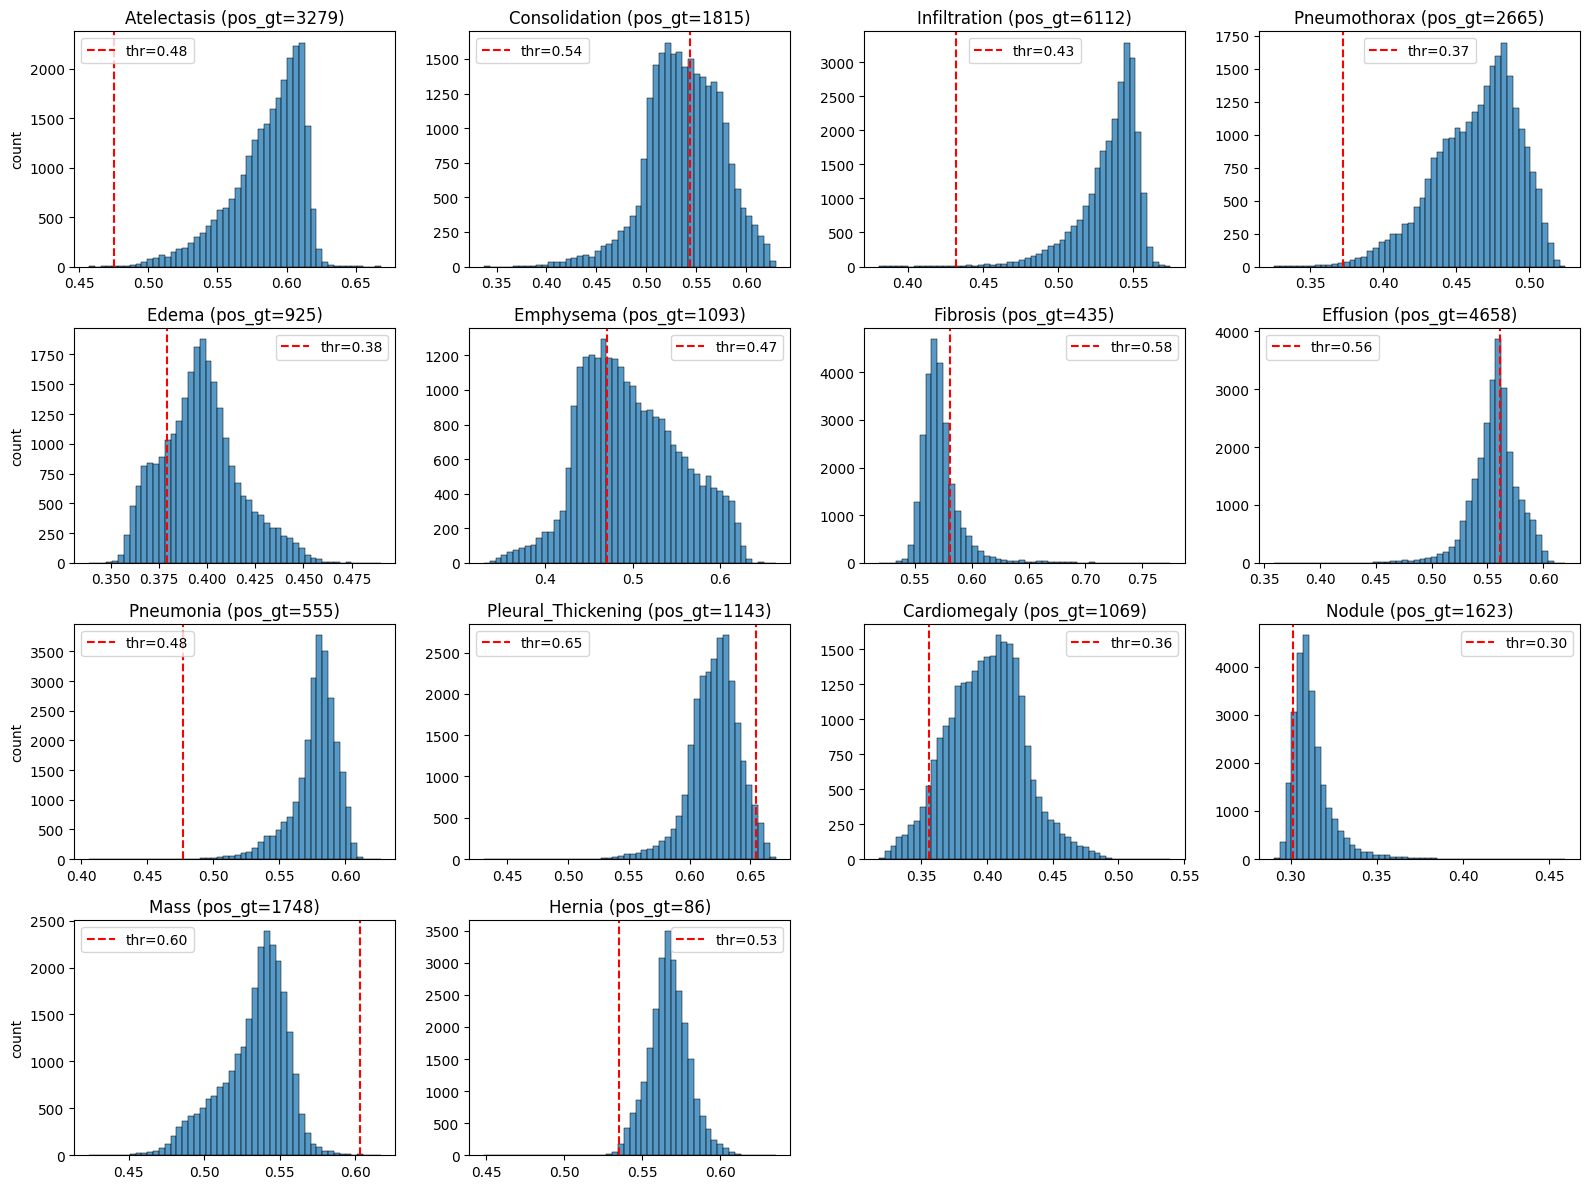


Ejemplos (hasta 20) de indices con GT>0 pero modelo no predijo nada (no_pred): 0 encontrados.
[]
No tienes 'image_names' en memoria


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_curve, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score


USE_OPTIMAL_THRESHOLDS = True   
FIXED_THRESHOLD = 0.5
PLOT_NCOLS = 4                  
FIGSIZE_PER_PLOT = (4,3)
SAVE_PLOTS = True
OUT_PREFIX = "eval_outputs"     


probs = np.array(all_outputs, dtype=float)   
labels = np.array(all_labels, dtype=int)    

if probs.min() < 0.0 or probs.max() > 1.0:
    probs = 1.0 / (1.0 + np.exp(-probs))

N, C = probs.shape
try:
    class_names
except NameError:
    class_names = [f"class_{i}" for i in range(C)]


# ===== REUTILIZAR UMBRALES PRECALCULADOS =====
# Verificar si ya tenemos umbrales calculados de celdas anteriores
try:
    thresholds  # verificar existencia
    if len(thresholds) == C:
        print("✓ Reutilizando umbrales óptimos precalculados de celdas anteriores:")
        for i, t in enumerate(thresholds):
            print(f"   - {class_names[i]}: {t:.3f}")
        thresholds_array = np.array(thresholds, dtype=float)
    else:
        raise ValueError("Dimensión incorrecta")
except (NameError, ValueError):
    # Si no existen o dimensión incorrecta, calcular desde cero
    print("⚠ Umbrales no encontrados, calculando con Youden's J...")
    thresholds_array = np.full(C, FIXED_THRESHOLD, dtype=float)
    if USE_OPTIMAL_THRESHOLDS:
        for i in range(C):
            y_true = labels[:, i]
            y_prob = probs[:, i]
            if np.sum(y_true) > 0 and np.sum(y_true) < len(y_true):  
                fpr, tpr, thr = roc_curve(y_true, y_prob)
                youden = tpr - fpr
                best_idx = np.nanargmax(youden)
                thresholds_array[i] = float(thr[best_idx])
            else:
                thresholds_array[i] = FIXED_THRESHOLD
        print("Nuevos thresholds calculados:")
        for i, t in enumerate(thresholds_array):
            print(f"   - {class_names[i]}: {t:.3f}")
        # Guardar para uso futuro
        thresholds = thresholds_array.tolist()


preds = (probs >= thresholds_array[np.newaxis, :]).astype(int)


no_true_mask = (labels.sum(axis=1) == 0)
num_no_true = int(no_true_mask.sum())
pct_no_true = num_no_true / N * 100.0

no_pred_mask = (preds.sum(axis=1) == 0)
num_no_pred = int(no_pred_mask.sum())
pct_no_pred = num_no_pred / N * 100.0

# de las imágenes enfermas, cuántas quedaron sin predicción (miss rate)
gt_positive_mask = ~no_true_mask
miss_on_sick_mask = no_pred_mask & gt_positive_mask
num_miss_on_sick = int(miss_on_sick_mask.sum())
pct_miss_on_sick = (num_miss_on_sick / max(1, gt_positive_mask.sum())) * 100.0

print("\nResumen global de samples:")
print(f" - Total samples: {N}")
print(f" - Samples sin patología en GT (all zeros): {num_no_true} ({pct_no_true:.2f}%)")
print(f" - Samples donde modelo no predijo ninguna clase: {num_no_pred} ({pct_no_pred:.2f}%)")
print(f" - Entre imágenes enfermas, misses (no_pred & tiene GT>0): {num_miss_on_sick} ({pct_miss_on_sick:.2f}%)")

rows = []
for i in range(C):
    y_true = labels[:, i]
    y_pred = preds[:, i]
    if np.unique(y_true).size == 1:
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        tp = np.sum((y_true == 1) & (y_pred == 1))
    else:
        cm = confusion_matrix(y_true, y_pred, labels=[0,1])
        tn, fp, fn, tp = cm.ravel()
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    pos_total = int(y_true.sum())
    miss_rate = (fn / pos_total) * 100.0 if pos_total > 0 else np.nan

    rows.append({
        "class": class_names[i],
        "threshold": float(thresholds_array[i]),
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
        "positives_gt": pos_total,
        "precision": float(prec), "recall": float(rec), "f1": float(f1), "accuracy": float(acc),
        "miss_rate_pct": miss_rate
    })

per_class_summary = pd.DataFrame(rows).sort_values(by='miss_rate_pct', ascending=False)
display(per_class_summary)
per_class_summary.to_csv(f"{OUT_PREFIX}_per_class_summary.csv", index=False)
print(f"\nPer-class summary saved to {OUT_PREFIX}_per_class_summary.csv")

ncols = PLOT_NCOLS
nrows = int(np.ceil(C / ncols))
fig_w = ncols * FIGSIZE_PER_PLOT[0]
fig_h = nrows * FIGSIZE_PER_PLOT[1]
fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))
axes = axes.flatten()

for i in range(C):
    ax = axes[i]
    sns.histplot(probs[:, i], bins=50, kde=False, stat='count', ax=ax)
    ax.axvline(thresholds_array[i], color='red', linestyle='--', label=f"thr={thresholds_array[i]:.2f}")
    ax.set_title(f"{class_names[i]} (pos_gt={int(labels[:,i].sum())})")
    if i % ncols == 0:
        ax.set_ylabel("count")
    else:
        ax.set_ylabel("")
    ax.legend()

for j in range(C, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
if SAVE_PLOTS:
    fname = f"{OUT_PREFIX}_prob_histograms.png"
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    print(f"Saved histograms to {fname}")
plt.show()

indices_missed = np.where(miss_on_sick_mask)[0]
print(f"\nEjemplos (hasta 20) de indices con GT>0 pero modelo no predijo nada (no_pred): {len(indices_missed)} encontrados.")
print(indices_missed[:20])

try:
    image_names  
    sample_df = pd.DataFrame({
        "idx": np.arange(N),
        "image_name": image_names,
        "num_gt_labels": labels.sum(axis=1),
        "num_pred_labels": preds.sum(axis=1),
        "no_pred": (preds.sum(axis=1) == 0),
        "miss_on_sick": miss_on_sick_mask
    })
    sample_df.to_csv(f"{OUT_PREFIX}_sample_summary_with_names.csv", index=False)
    print(f"Saved sample summary with image names to {OUT_PREFIX}_sample_summary_with_names.csv")
except NameError:
    print("No tienes 'image_names' en memoria")

# Gradcam para ver qué partes de la imagen se fija el modelo para hacer la clasificación

Primero encuentra las imagenes que el modelo clasificó con la mayor probabilidad para cada una de las 14 clases. Luego genera los gradcams para esas imágenes. 

Detectado meta_dim: 3
GradCAM listo. Target layer: orig.cnn.0.denseblock4.denselayer16.conv2


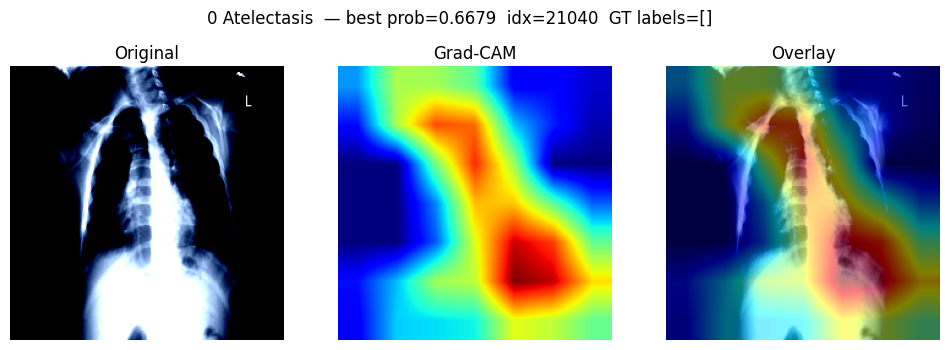

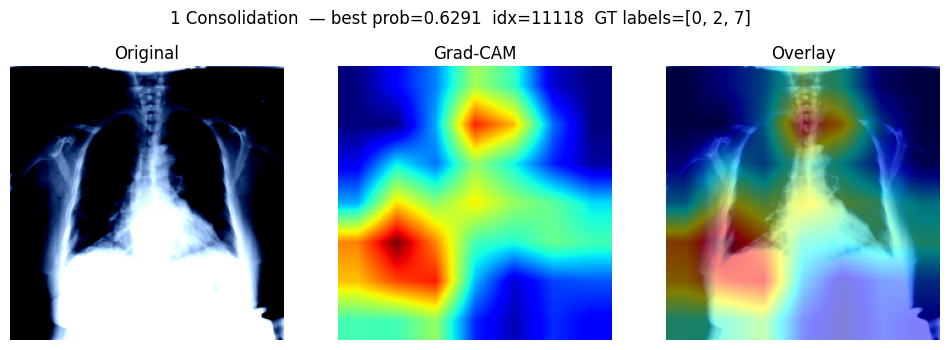

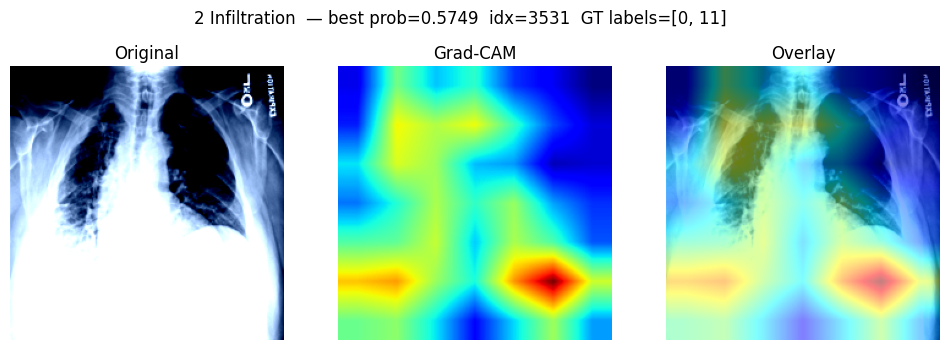

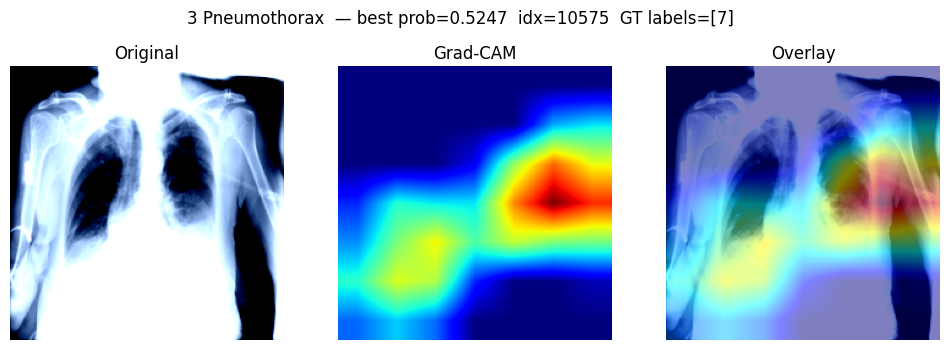

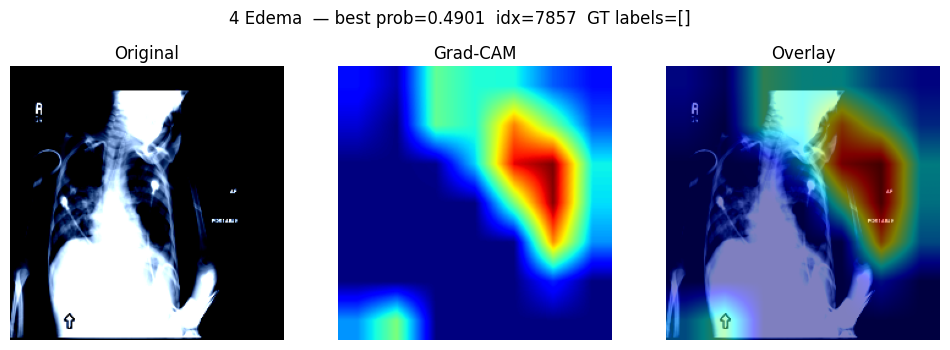

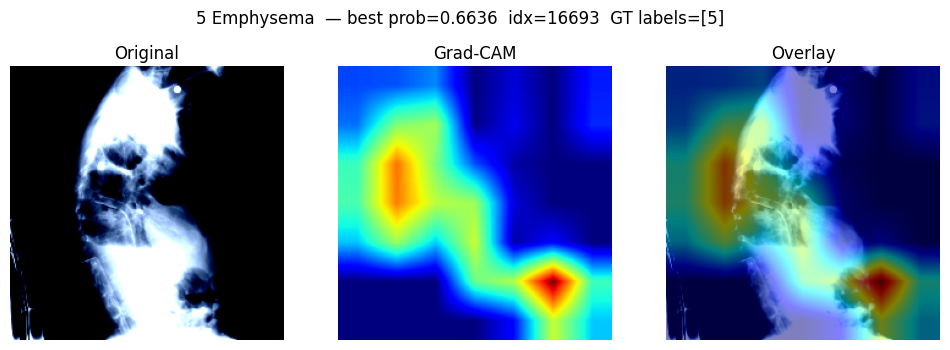

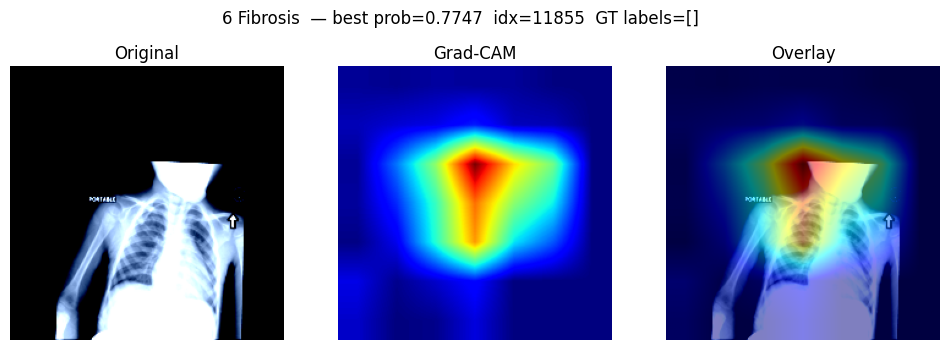

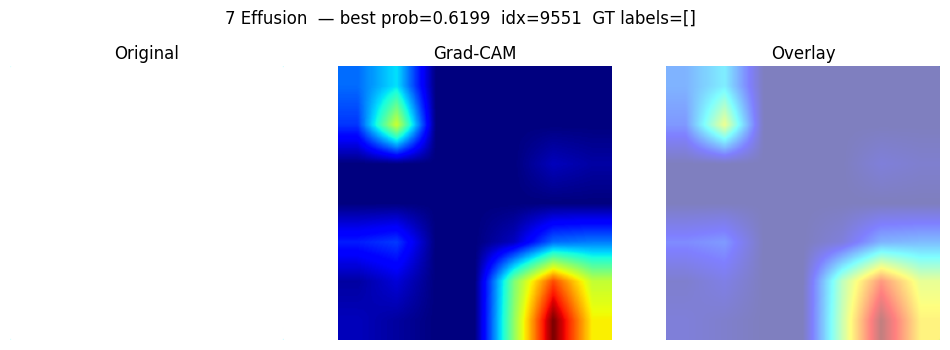

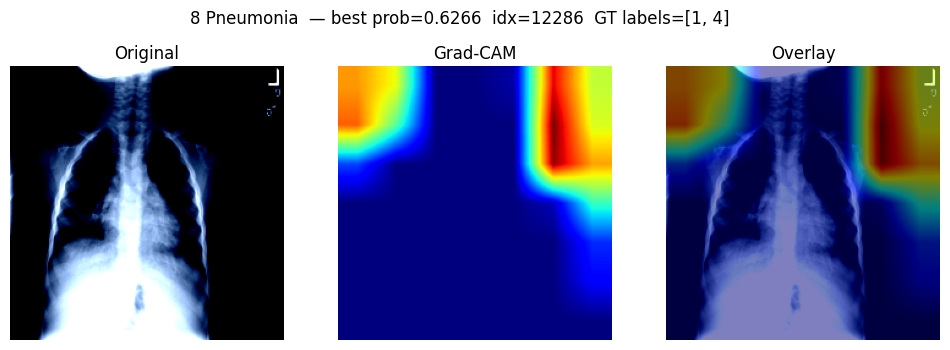

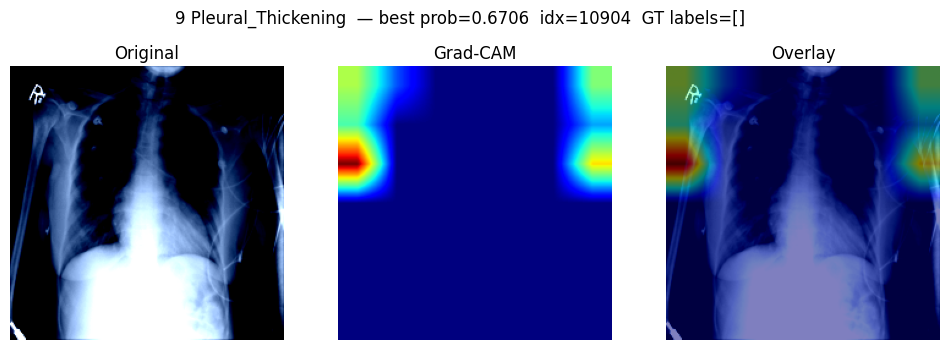

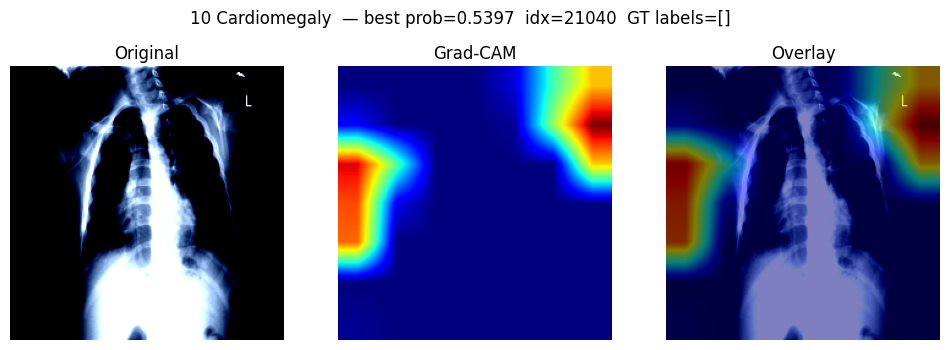

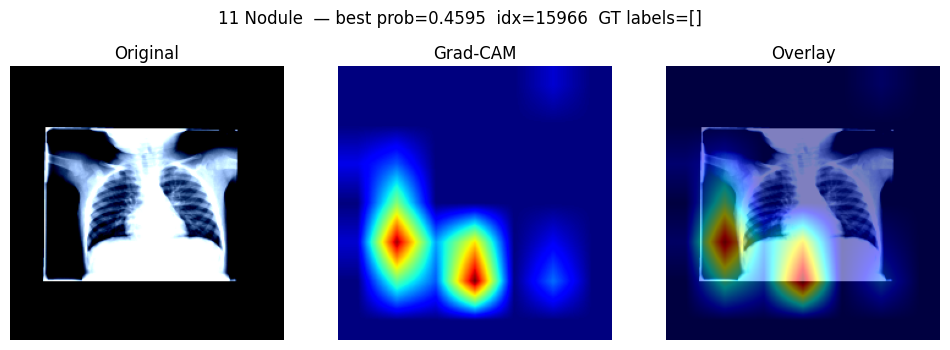

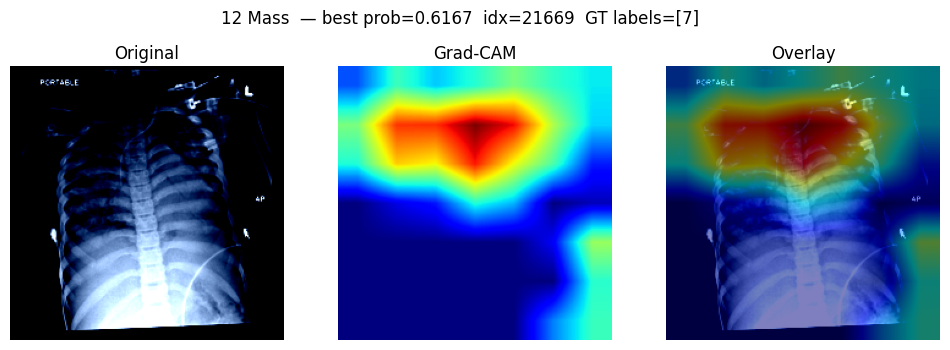

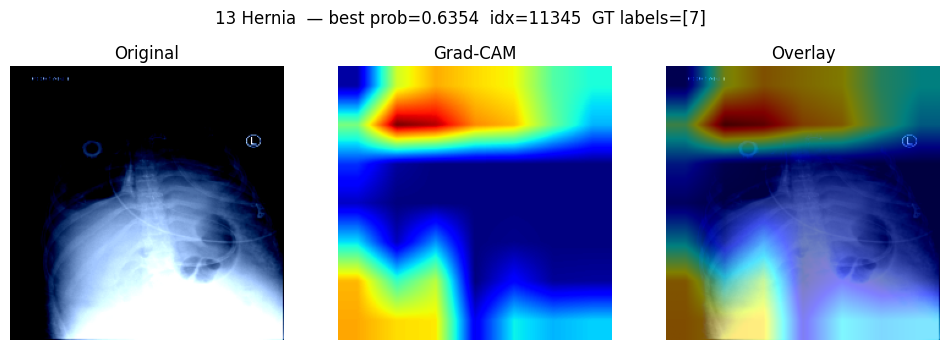

Guardadas imágenes en /home/project_cv_um/ProyectoCNN/gradcam_best_per_class


In [18]:
!pip install opencv-python matplotlib --quiet

import torch
import torch.nn as nn
import numpy as np
import cv2
from pathlib import Path
import matplotlib.pyplot as plt

def tensor_to_image_np(tensor):
    """Convierte tensor 1xC x H x W (valores en [0,1] o normalize inv) a HxWx3 float [0,1]."""
    t = tensor.detach().cpu().squeeze(0).numpy()
    if t.shape[0] == 1:
        img = np.repeat(t, 3, axis=0)
    else:
        img = t
    img = img.transpose(1,2,0)
    img = np.clip(img, 0, 1)
    return img

def overlay_heatmap_on_image(img_np, heatmap, alpha=0.5, colormap=cv2.COLORMAP_JET):
    """img_np: HxWx3 [0,1], heatmap: HxW [0,1]"""
    hm = (255 * heatmap).astype(np.uint8)
    hm_color = cv2.applyColorMap(hm, colormap)[:,:,::-1] / 255.0  # BGR->RGB
    overlay = (1-alpha) * img_np + alpha * hm_color
    overlay = np.clip(overlay, 0, 1)
    return overlay

def find_last_conv_name(model):
    last_name = None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_name = name
    return last_name

class GradCAM:
    def __init__(self, model, target_layer_name=None):
        self.model = model
        self.model.eval()
        self.device = next(model.parameters()).device
        if target_layer_name is None:
            target_layer_name = find_last_conv_name(model)
            if target_layer_name is None:
                raise ValueError("No se encontró capa Conv2d automática; pasa target_layer_name manualmente.")
        self.target_layer_name = target_layer_name
        self.activations = None
        self.gradients = None
        # registrar hooks
        for name, module in self.model.named_modules():
            if name == target_layer_name:
                module.register_forward_hook(self._forward_hook)
                try:
                    module.register_full_backward_hook(self._backward_hook)
                except AttributeError:
                    module.register_backward_hook(self._backward_hook)
                break
        else:
            raise ValueError(f"target layer {target_layer_name} no encontrado en el modelo.")

    def _forward_hook(self, module, input, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, input_tensor, class_idx):
        self.model.zero_grad()
        self.activations = None
        self.gradients = None

        logits = self.model(input_tensor)
        if logits.ndim == 1:
            logits = logits.unsqueeze(0)
        score = logits[0, class_idx]
        score.backward(retain_graph=True)
        
        if self.activations is None or self.gradients is None:
            raise RuntimeError("Hooks no capturaron activaciones o gradientes.")

        grads = self.gradients[0]
        acts = self.activations[0]

        weights = torch.mean(grads.view(grads.shape[0], -1), dim=1)
        cam = torch.zeros(acts.shape[1:], dtype=torch.float32).to(self.device)

        for i, w in enumerate(weights):
            cam += w * acts[i]
        cam = torch.relu(cam)
        cam = cam.cpu().numpy()
        
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        
        H = input_tensor.shape[-2]
        W = input_tensor.shape[-1]
        cam = cv2.resize(cam, (W, H))
        return cam, logits.detach().cpu().numpy()

class ModelForGradCAM(nn.Module):
    def __init__(self, orig_model, meta_dim, meta_default=None):
        super().__init__()
        self.orig = orig_model
        self.meta_dim = meta_dim
        if meta_default is not None:
            if isinstance(meta_default, np.ndarray):
                meta_default = torch.tensor(meta_default, dtype=torch.float32)
        self.meta_default = meta_default

    def forward(self, x):
        batch = x.shape[0]
        device = x.device
        if self.meta_default is None:
            meta = torch.zeros((batch, self.meta_dim), device=device, dtype=torch.float32)
        else:
            md = self.meta_default.to(device).detach()
            if md.dim() == 1:
                md = md.unsqueeze(0)
            meta = md.expand(batch, -1).to(device)
        return self.orig(x, meta)

# Detectar meta_dim y preparar modelo
try:
    sample_batch = next(iter(test_loader))
    _, sample_meta, _ = sample_batch
    meta_dim = sample_meta.shape[1]
    print("Detectado meta_dim:", meta_dim)
except Exception as e:
    raise RuntimeError("No pude detectar meta_dim desde test_loader.") from e

# Preparar wrapped model y GradCAM
wrapped_model = ModelForGradCAM(model, meta_dim=meta_dim, meta_default=None).to(device)
wrapped_model.eval()

last_conv = find_last_conv_name(wrapped_model)
if last_conv is None:
    raise RuntimeError("No se encontró ninguna capa Conv2d en el modelo.")

gradcam = GradCAM(wrapped_model, target_layer_name=last_conv)
print("GradCAM listo. Target layer:", last_conv)

# Configuración
DATA_LOADER = test_loader    
OUT_DIR = Path("gradcam_best_per_class")
OUT_DIR.mkdir(parents=True, exist_ok=True)


class_names = DISEASE_COLUMNS

C = len(class_names)

# Encontrar las mejores predicciones por clase
best = [{"prob": -1.0, "img_tensor": None, "label": None, "idx": None} for _ in range(C)]

idx_global = 0
with torch.no_grad():
    for images, meta, labels in DATA_LOADER:
        bs = images.size(0)
        images_gpu = images.to(device, non_blocking=True)
        meta_gpu = meta.to(device, non_blocking=True)
        logits = model(images_gpu, meta_gpu)
        probs = torch.sigmoid(logits).cpu().numpy()
        labels_np = labels.cpu().numpy()
        
        for b in range(bs):
            for cls in range(C):
                p = float(probs[b, cls])
                if p > best[cls]["prob"]:
                    best[cls]["prob"] = p
                    best[cls]["img_tensor"] = images[b:b+1].cpu().detach()
                    best[cls]["label"] = labels_np[b].copy()
                    best[cls]["idx"] = idx_global + b
        idx_global += bs

# Generar y guardar GradCAMs
for i in range(C):
    info = best[i]
    cls_name = class_names[i]
    if info["img_tensor"] is None:
        print(f"Clase {cls_name}: no se encontraron imágenes.")
        continue

    img_tensor_cpu = info["img_tensor"]
    prob = info["prob"]
    idx = info["idx"]
    label = info["label"]

    input_tensor = img_tensor_cpu.to(device)

    try:
        cam, _ = gradcam(input_tensor, i)
    except Exception as e:
        print(f"GradCAM failed para {cls_name} idx {idx}: {e}")
        continue

    img_np = tensor_to_image_np(img_tensor_cpu)
    overlay = overlay_heatmap_on_image(img_np, cam, alpha=0.5)

    plt.figure(figsize=(12,4))
    plt.suptitle(f"{i} {cls_name}  — best prob={prob:.4f}  idx={idx}  GT labels={np.where(label==1)[0].tolist()}")
    plt.subplot(1,3,1)
    plt.imshow(img_np); plt.title("Original"); plt.axis('off')
    plt.subplot(1,3,2)
    plt.imshow(cam, cmap='jet'); plt.title("Grad-CAM"); plt.axis('off')
    plt.subplot(1,3,3)
    plt.imshow(overlay); plt.title("Overlay"); plt.axis('off')

    cls_dir = OUT_DIR / f"{i}_{cls_name.replace('/','_')}"
    cls_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(cls_dir / f"best_idx{idx}_prob{prob:.4f}.png", bbox_inches='tight', dpi=200)
    plt.show()

print(f"Guardadas imágenes en {OUT_DIR.resolve()}")


# Generar un diagrama de la arquitectura del modelo

In [ ]:

!pip install torchinfo --quiet
from torchinfo import summary
from CNNTransformerFusion import CNNTransformerFusion

model = CNNTransformerFusion(num_classes=num_classes).to(device)

summary(model, input_data=[torch.randn(1,3,224,224).to(device),
                           torch.randn(1,meta_dim).to(device)])
!pip install torchviz graphviz --quiet
from torchviz import make_dot

images = torch.randn(1,3,224,224).to(device)
meta = torch.randn(1,meta_dim).to(device)

model = CNNTransformerFusion(num_classes=num_classes).to(device)
output = model(images, meta)


dot = make_dot(output, params=dict(model.named_parameters()))

dot.format = 'png'
dot.render('cnntransformer_architecture')